In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append('../src/')
#Required to save figures
import os

In [2]:
import utils
import importlib
importlib.reload(utils)

<module 'utils' from '/home/brokrab/Documents/GalaxyFormation_MegaDirectory/Galaxy_Formation_Research/SFRD_Probes/Notebooks/../src/utils.py'>

In [3]:
h = 0.67 

Om_m = 0.315            # matter density
Om_b = 0.022/(h*h)      # baryonic matter density
Om_lambda = 0.685       # vacuum energy density

rho_c = 2.78e11 *h*h    # in units of M_s/Mpc^3

# mean matter density of the universe
rho_0 = Om_m * rho_c    # in units of M_s/Mpc^3
delta_c = 1.686         # Critical density for spherical collapse

# for normalising the power spectrum
sigma8_obs = 0.811      # Observed value of sigma_8
n = 0.965               # power spectrum P(k)~ k^n

z_range = np.linspace(0.1,20, 100)

from numba import jit

f_b = Om_b/Om_m     # fraction of baryonic matter
H0 = h/9.78e9         # in units of 1/yr

#  Accretion Shocks

## Relativistic Electron Energy Density

In [4]:
def E_bb(M, z): #Baryon binding energy of a halo of mass M (in SM) at redshift z in erg
    Om_m_z = Om_m * (1 + z) ** 3 / (Om_m * (1 + z) ** 3 + Om_lambda)
    d = Om_m_z - 1
    delta_c = 18 * np.pi ** 2 + 82 * d - 39 * d ** 2
    baryon_frac = Om_b / Om_m #Need only baryon binding energy
    return 5.45 * 10 ** (53) * (M * h / 10 ** 8) ** (5 / 3) * (Om_m / Om_m_z * delta_c / (18 * np.pi ** 2)) ** (1 / 3) * (1 + z) / (10 * h) * baryon_frac

In [5]:
min_T_vir = 10 ** 4 #Efficient atomic cooling above this temp

neutral_mu = 1.23
k_B_SI = 1.38 * 10 ** (-23) #m^2 kg s^-2 K^-1
m_p_kg = 1.67 * 10 ** (-27) #kg

min_V_c = np.sqrt(min_T_vir * 2 * (k_B_SI / (1000) ** 2) / (neutral_mu * m_p_kg))

def M_factor(z): #The coefficient of M^1/3 in V_c formula
    Om_m_z = Om_m * (1 + z) ** 3 / (Om_m * (1 + z) ** 3 + Om_lambda)
    d = Om_m_z - 1
    delta_c = 18 * np.pi ** 2 + 82 * d - 39 * d ** 2
    return 23.4 * (Om_m / Om_m_z * delta_c / (18 * np.pi ** 2)) ** (1 / 6) * ((1 + z) / 10) ** (1 / 2) / (10 ** 8 * h ** (-1)) ** (1 / 3)

def M_crit(z):
    return (min_V_c / M_factor(z)) ** (3)

In [6]:
M_range = np.logspace(6, 16, 500)  # Mass range in solar masses

M_arrs_inz = [] #Mass range set by V_c critical

for i in range(len(z_range)):
    arr = np.logspace(np.log10(M_crit(z_range[i])), 16, 500)
    M_arrs_inz.append(arr)

M_arrs_inz = np.array(M_arrs_inz)

In [7]:
from utils import PS_MassFunc

In [8]:
"""

dn_dlogM_new = np.zeros((len(M_range), len(z_range)))
integrand_rel_en_dens = np.zeros((len(M_range), len(z_range)))

f_r = 0.1 #fraction of binding energy going into relativistic electrons

for i in range(len(z_range)):
    for j in range(len(M_range)):
        dn_dlogM_new[j, i] = PS_MassFunc(M_arrs_inz[i][j], z_range[i]) * (rho_0 / M_arrs_inz[i][j])
        integrand_rel_en_dens[j, i] = dn_dlogM_new[j, i] * f_r * E_bb(M_arrs_inz[i][j], z_range[i])

"""

'\n\ndn_dlogM_new = np.zeros((len(M_range), len(z_range)))\nintegrand_rel_en_dens = np.zeros((len(M_range), len(z_range)))\n\nf_r = 0.1 #fraction of binding energy going into relativistic electrons\n\nfor i in range(len(z_range)):\n    for j in range(len(M_range)):\n        dn_dlogM_new[j, i] = PS_MassFunc(M_arrs_inz[i][j], z_range[i]) * (rho_0 / M_arrs_inz[i][j])\n        integrand_rel_en_dens[j, i] = dn_dlogM_new[j, i] * f_r * E_bb(M_arrs_inz[i][j], z_range[i])\n\n'

In [9]:
"""

Rel_energy_dens = np.trapezoid(integrand_rel_en_dens, x=np.log10(M_range), axis=0)

"""

'\n\nRel_energy_dens = np.trapezoid(integrand_rel_en_dens, x=np.log10(M_range), axis=0)\n\n'

In [10]:
dn_dlogM_new = np.zeros((len(M_range), len(z_range)))
integrand_rel_en_dens = np.zeros((len(M_range), len(z_range)))

f_r = 0.1

Rel_energy_dens = np.zeros(len(z_range))

for i in range(len(z_range)):

    for j in range(len(M_range)):
        M = M_arrs_inz[i][j]

        dn_dlogM_new[j, i] = PS_MassFunc(M, z_range[i]) * (rho_0 / M)
        integrand_rel_en_dens[j, i] = (
            dn_dlogM_new[j, i]
            * f_r
            * E_bb(M, z_range[i])
        )

    Rel_energy_dens[i] = np.trapezoid(
        integrand_rel_en_dens[:, i],
        x=np.log10(M_arrs_inz[i])
    )

'\n\nsave_dir = "/home/brokrab/Documents/GalaxyFormation_MegaDirectory/Galaxy_Formation_Research/SFRD_Probes/Figures/Alt_XRay_Sources/"\n\n# Create folder if it doesn\'t exist\nos.makedirs(save_dir, exist_ok=True)\n\n# Full path to output file\nsave_path = os.path.join(save_dir, "RelElecEnergyDens.png")\n\n# Save figure\nplt.savefig(save_path, dpi=300, bbox_inches="tight")\n\n'

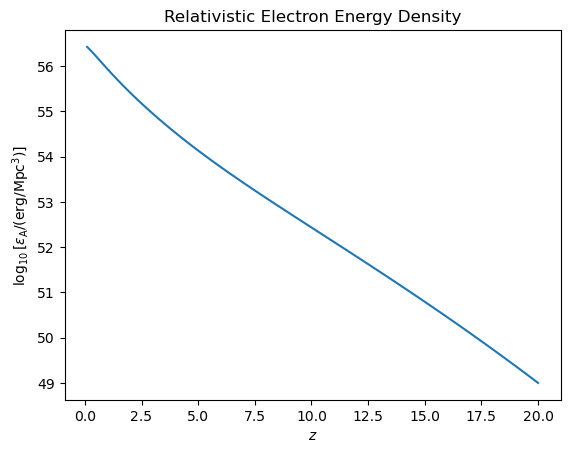

In [11]:
plt.plot(z_range, np.log10(Rel_energy_dens))
plt.ylabel(r'$\log_{10}[\epsilon_\text{A}/(\text{erg/Mpc}^{3})]$')
plt.xlabel(r'$z$')
plt.title(r'Relativistic Electron Energy Density')

"""

save_dir = "/home/brokrab/Documents/GalaxyFormation_MegaDirectory/Galaxy_Formation_Research/SFRD_Probes/Figures/Alt_XRay_Sources/"

# Create folder if it doesn't exist
os.makedirs(save_dir, exist_ok=True)

# Full path to output file
save_path = os.path.join(save_dir, "RelElecEnergyDens.png")

# Save figure
plt.savefig(save_path, dpi=300, bbox_inches="tight")

"""

## Thermal Background Energy Density

In [12]:
def n_gas(z): #Gas density as a function of redshift
    neutral_mu = 1.23
    m_p = 1.67 * 10 ** (-27) * (5.03 * 10 ** (-31)) #Solar mass
    rho_b0 = Om_b * rho_c
    n_0 = rho_b0 / (neutral_mu * m_p)
    return n_0 * (1 + z) ** 3

In [13]:
n_arr = np.zeros_like(z_range)

for i in range(len(z_range)):
    n_arr[i] = n_gas(z_range[i])

Text(0, 0.5, '$n_\\text{gas}(z)$ (Mpc$^{-3}$)')

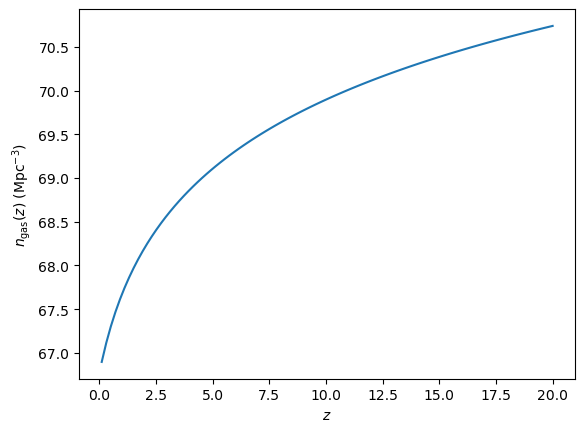

In [14]:
plt.plot(z_range, np.log10(n_arr))
plt.xlabel(r'$z$')
plt.ylabel(r'$n_\text{gas}(z)$ (Mpc$^{-3}$)')

In [15]:
def E_thermal_dens(z, T): #Inputing z and T arr we have already calculated
    k_B = 1.38 * 10 ** (-16) #in CGS
    neutral_mu = 1.23
    m_p = 1.67 * 10 ** (-27) * (5.03 * 10 ** (-31)) #Solar mass
    rho_b0 = Om_b * rho_c
    n_0 = rho_b0 / (neutral_mu * m_p)
    T_arr = np.zeros_like(z)
    for i in range(len(z)):
        T_arr[i] = 3 / 2 * n_0 * k_B * T * (1 + z[i]) ** 3
    return T_arr

In [16]:
Thermal_energy_dens1 = E_thermal_dens(z_range, 10)
Thermal_energy_dens2 = E_thermal_dens(z_range, 100)
Thermal_energy_dens3 = E_thermal_dens(z_range, 10**4)

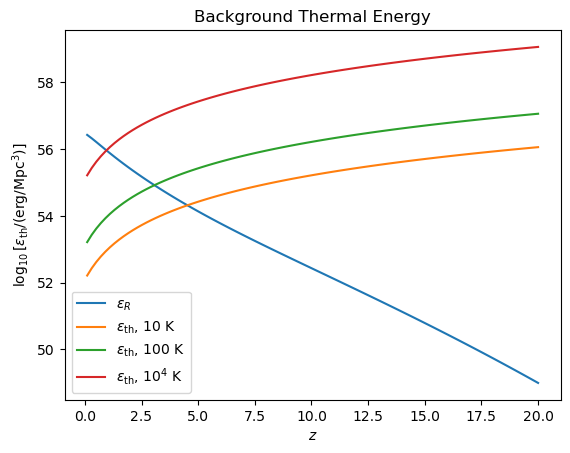

In [17]:
plt.plot(z_range, np.log10(Rel_energy_dens), label = r'$\epsilon_R$')
plt.plot(z_range, np.log10(Thermal_energy_dens1), label = r'$\epsilon_\text{th}$, 10 K')
plt.plot(z_range, np.log10(Thermal_energy_dens2), label = r'$\epsilon_\text{th}$, 100 K')
plt.plot(z_range, np.log10(Thermal_energy_dens3), label = r'$\epsilon_\text{th}$, $10^4$ K')
plt.xlabel(r'$z$')
plt.ylabel(r'$\log_{10}[\epsilon_\text{th}/(\text{erg/Mpc}^3)]$')
plt.title(r'Background Thermal Energy')
plt.legend()

In [18]:
Energy_dens_ratio1 = Rel_energy_dens / Thermal_energy_dens1
Energy_dens_ratio2 = Rel_energy_dens / Thermal_energy_dens2
Energy_dens_ratio3 = Rel_energy_dens / Thermal_energy_dens3

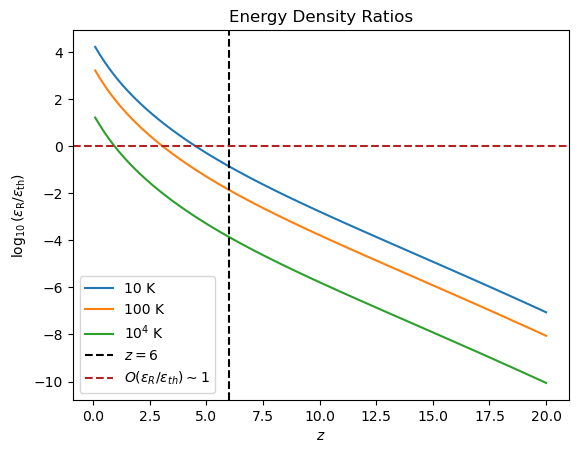

In [19]:
plt.plot(z_range, np.log10(Energy_dens_ratio1), label = r'10 K')
plt.plot(z_range, np.log10(Energy_dens_ratio2), label = r'100 K')
plt.plot(z_range, np.log10(Energy_dens_ratio3), label = r'$10^4$ K')
plt.xlabel(r'$z$')
plt.ylabel(r'$\log_{10}(\epsilon_\text{R}/\epsilon_\text{th})$')
plt.title(r'Energy Density Ratios')
plt.axvline(6, ls = '--', color = r'black', label = r'$z=6$')
plt.axhline(0, ls = '--', color = r'firebrick', label = r'$O(\epsilon_R/\epsilon_{th})\sim1$')
plt.legend()

In [20]:
crossings = np.where(np.diff(np.sign(Energy_dens_ratio3 - 1)))[0]

z_cross = z_range[crossings[0]]
print(z_cross)

0.904040404040404


# Emissivity Comparizon Plot

## HMXBS

In [21]:
from utils import Madau

In [22]:
SFRD_vals = np.zeros_like(z_range)
HMXB_Em_vals = np.zeros_like(z_range)

L_HMXB = 10 ** (40)

for i in range(len(z_range)):
    SFRD_vals[i] = Madau(z_range[i])
    HMXB_Em_vals[i] = L_HMXB * SFRD_vals[i]

## LMXBs

In [23]:
def H(z): #in km/s/Mpc
    return 67 * np.sqrt( Om_m*(1+z)**3 + Om_lambda )

Mpctokm = 3.086 * 10 ** (19)
SectoYr = 1 / (3.154 * 10 ** 7)

def dt_dz(z): #In yr
    return -1 / ((1 + z) * H(z) / (SectoYr * Mpctokm))

In [24]:
def LM_Int(z):
    return Madau(z) * np.abs(dt_dz(z))

In [25]:
LM_Int_vals = np.zeros_like(z_range)

for i in range(len(z_range)):
    LM_Int_vals[i] = LM_Int(z_range[i])

In [26]:
Madau_vals = Madau(z_range)

In [27]:
from scipy.integrate import cumulative_trapezoid

In [28]:
z = z_range                # ascending: 0 → 20
f = LM_Int(z)

# cumulative integral from 0 → z
cum_int = cumulative_trapezoid(f, z, initial=0)

# total integral from 0 → 20
total = cum_int[-1]

# desired: integral from z → 20
F = total - cum_int

In [29]:
L_LMXB = 10 ** (30.5)

Ret_fact = 0.39

LMXB_Em_vals = L_LMXB * F * (1 - Ret_fact)

## Accretion Shocks

In [30]:
Yrtosec = 3.154 * 10 ** 7
Mpctokm = 3.086 * 10 ** (19)

def Time_ff(z):
    return 1 / np.sqrt(27 * np.pi ** 2 * (H(z) / Mpctokm) ** 2)

In [31]:
Time_ff_vals = Time_ff(z_range)

AccShocks_Em_vals = Rel_energy_dens / Time_ff_vals

In [32]:
H(z_range)

array([  70.40628939,   78.66922585,   88.69408888,  100.29624007,
        113.29535507,  127.53452002,  142.88419085,  159.23962869,
        176.51646699,  194.64637317,  213.57342772,  233.25129304,
        253.64106113,  274.70963373,  296.42850384,  318.77283485,
        341.72075909,  365.25283847,  389.35164565,  414.00143519,
        439.1878828 ,  464.89787633,  491.11934666,  517.8411295 ,
        545.05285149,  572.7448354 ,  600.90802071,  629.53389647,
        658.61444421,  688.14208894,  718.10965696,  748.51033924,
        779.33765944,  810.5854459 ,  842.24780693,  874.31910892,
        906.79395685,  939.66717696,  972.93380109, 1006.58905269,
       1040.62833414, 1075.04721525, 1109.84142286, 1145.00683129,
       1180.53945368, 1216.43543404, 1252.69103989, 1289.30265558,
       1326.26677604, 1363.58000108, 1401.23903004, 1439.24065686,
       1477.58176552, 1516.25932574, 1555.270389  , 1594.61208484,
       1634.28161734, 1674.27626191, 1714.59336218, 1755.23032

/tmp/ipykernel_200339/179818335.py:1: RuntimeWarning: divide by zero encountered in log10
  plt.plot(z_range, np.log10(LMXB_Em_vals), label = r'LMXB')


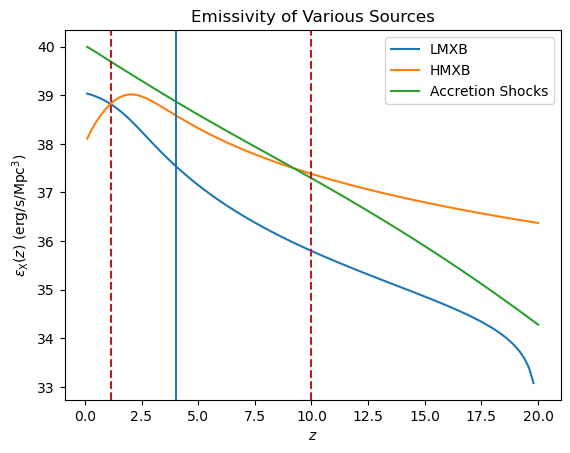

In [33]:
plt.plot(z_range, np.log10(LMXB_Em_vals), label = r'LMXB')
plt.plot(z_range, np.log10(HMXB_Em_vals), label = r'HMXB')
plt.plot(z_range, np.log10(AccShocks_Em_vals), label = r'Accretion Shocks')

plt.xlabel(r'$z$')
plt.ylabel(r'$\epsilon_\text{X}(z)$ (erg/s/Mpc$^3$)')
plt.title(r'Emissivity of Various Sources')
plt.legend()
plt.axvline(10, ls = '--', color = r'firebrick')
plt.axvline(1.15, ls = '--', color = r'firebrick')
plt.axvline(4)

## Varying $f_\text{R}$

In [34]:
f_r_2 = 0.05
f_r_3 = 0.01

nM = len(M_arrs_inz[0])
nz = len(z_range)

dn_dlogM_new_2 = np.zeros((nM, nz))
integrand_rel_en_dens_2 = np.zeros((nM, nz))
Rel_energy_dens_2 = np.zeros(nz)

for i in range(nz):
    for j in range(nM):
        M = M_arrs_inz[i][j]

        dn_dlogM_new_2[j, i] = PS_MassFunc(M, z_range[i]) * (rho_0 / M)
        integrand_rel_en_dens_2[j, i] = (
            dn_dlogM_new_2[j, i] * f_r_2 * E_bb(M, z_range[i])
        )

    Rel_energy_dens_2[i] = np.trapezoid(
        integrand_rel_en_dens_2[:, i],
        x=np.log10(M_arrs_inz[i])
    )


dn_dlogM_new_3 = np.zeros((nM, nz))
integrand_rel_en_dens_3 = np.zeros((nM, nz))
Rel_energy_dens_3 = np.zeros(nz)

for i in range(nz):
    for j in range(nM):
        M = M_arrs_inz[i][j]

        dn_dlogM_new_3[j, i] = PS_MassFunc(M, z_range[i]) * (rho_0 / M)
        integrand_rel_en_dens_3[j, i] = (
            dn_dlogM_new_3[j, i] * f_r_3 * E_bb(M, z_range[i])
        )

    Rel_energy_dens_3[i] = np.trapezoid(
        integrand_rel_en_dens_3[:, i],
        x=np.log10(M_arrs_inz[i])
    )

In [35]:
Rel_energy_dens_2 = np.zeros(len(z_range))
Rel_energy_dens_3 = np.zeros(len(z_range))

for i in range(len(z_range)):
    Rel_energy_dens_2[i] = np.trapezoid(
        integrand_rel_en_dens_2[:, i],
        x=np.log10(M_arrs_inz[i])
    )

    Rel_energy_dens_3[i] = np.trapezoid(
        integrand_rel_en_dens_3[:, i],
        x=np.log10(M_arrs_inz[i])
    )

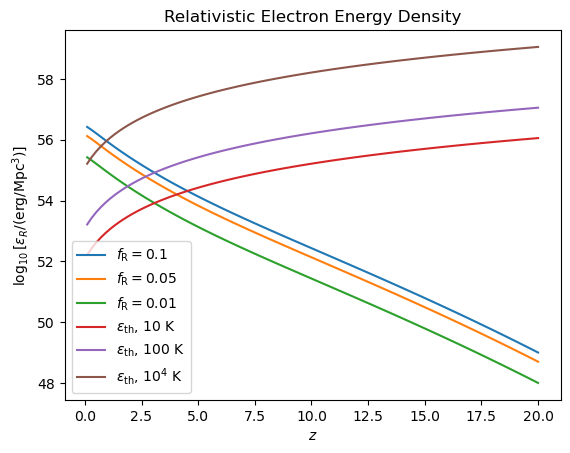

In [36]:
plt.plot(z_range, np.log10(Rel_energy_dens), label = r'$f_\text{R}=0.1$')
plt.plot(z_range, np.log10(Rel_energy_dens_2), label = r'$f_\text{R}=0.05$')
plt.plot(z_range, np.log10(Rel_energy_dens_3), label = r'$f_\text{R}=0.01$')
plt.ylabel(r'$\log_{10}[\epsilon_R/(\text{erg/Mpc}^{3})]$')
plt.xlabel(r'$z$')
plt.title(r'Relativistic Electron Energy Density')

plt.plot(z_range, np.log10(Thermal_energy_dens1), label = r'$\epsilon_\text{th}$, 10 K')
plt.plot(z_range, np.log10(Thermal_energy_dens2), label = r'$\epsilon_\text{th}$, 100 K')
plt.plot(z_range, np.log10(Thermal_energy_dens3), label = r'$\epsilon_\text{th}$, $10^4$ K')

plt.legend()

In [37]:
AccShocks_Em_vals_2 = Rel_energy_dens_2 / Time_ff_vals
AccShocks_Em_vals_3 = Rel_energy_dens_3 / Time_ff_vals

/tmp/ipykernel_200339/3214769952.py:1: RuntimeWarning: divide by zero encountered in log10
  plt.plot(z_range, np.log10(LMXB_Em_vals), label = r'LMXB', ls = '--')


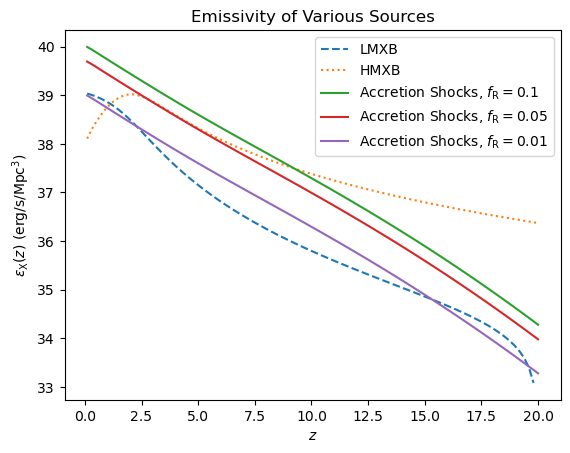

In [38]:
plt.plot(z_range, np.log10(LMXB_Em_vals), label = r'LMXB', ls = '--')
plt.plot(z_range, np.log10(HMXB_Em_vals), label = r'HMXB', ls = ':')
plt.plot(z_range, np.log10(AccShocks_Em_vals), label = r'Accretion Shocks, $f_\text{R}=0.1$')
plt.plot(z_range, np.log10(AccShocks_Em_vals_2), label = r'Accretion Shocks, $f_\text{R}=0.05$')
plt.plot(z_range, np.log10(AccShocks_Em_vals_3), label = r'Accretion Shocks, $f_\text{R}=0.01$')

plt.xlabel(r'$z$')
plt.ylabel(r'$\epsilon_\text{X}(z)$ (erg/s/Mpc$^3$)')
plt.title(r'Emissivity of Various Sources')
plt.legend()
#plt.axvline(10, ls = '--', color = r'firebrick')
#plt.axvline(1.15, ls = '--', color = r'firebrick')
#plt.axvline(4)